In [29]:
import collections
import re
import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l
import random

d2l.use_svg_display()

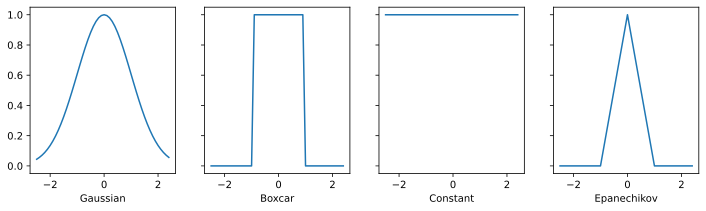

In [30]:
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

# fig是图像对象，axes是一个包含所有子图坐标轴对象的数组
fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

d2l.plt.show()

In [31]:
def f(x):
    return 2 * torch.sin(x) + x

n = 50
# 返回了一个一维tensor，里面有n个0到5之间的随机数
x_train, _ = torch.sort(torch.rand(n) * 5)
y_train = f(x_train) + torch.randn(n)#训练数据集
x_val = torch.arange(0, 5, 0.1)
y_val = f(x_val)#评估值
print(x_train)
print(x_val)

tensor([0.0211, 0.1287, 0.2231, 0.2263, 0.3261, 0.3913, 0.4070, 0.5475, 0.5719,
        0.7412, 0.7724, 0.9492, 0.9536, 1.0466, 1.0537, 1.0718, 1.1518, 1.1670,
        1.3010, 1.3307, 1.4295, 1.4562, 1.6328, 1.9658, 1.9809, 2.1704, 2.4680,
        2.4919, 2.5469, 2.8988, 2.9587, 3.1366, 3.2242, 3.3491, 3.4420, 3.5998,
        3.9034, 3.9589, 4.0317, 4.0641, 4.0750, 4.2142, 4.2916, 4.2923, 4.3796,
        4.4602, 4.6164, 4.6612, 4.8922, 4.9519])
tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
        1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
        2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
        3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
        4.5000, 4.6000, 4.7000, 4.8000, 4.9000])


In [36]:
def nadaraya_watson(x_train, y_train, x_val, kernel):
    # Compute the pairwise distances between training and validation points
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    print(dists.shape)
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    y_hat = y_train@attention_w
    return y_hat, attention_w

torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50, 50])
torch.Size([50, 50])


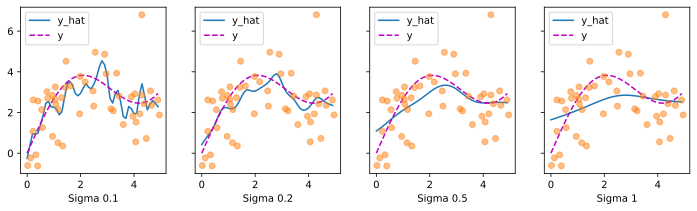

In [37]:
def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().numpy(), cmap='Reds')
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, 'm--')
            ax.plot(x_train, y_train, 'o', alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend(['y_hat', 'y'])
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)

plot(x_train, y_train, x_val, y_val, kernels, names)

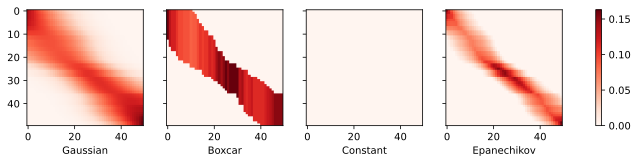

In [34]:
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)

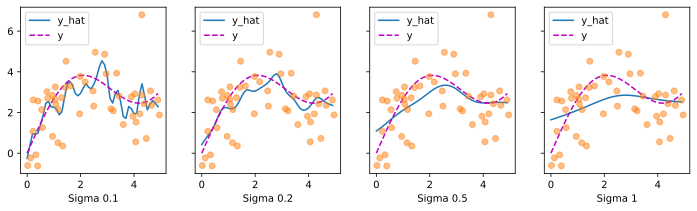

In [35]:
sigmas = (0.1, 0.2, 0.5, 1)
names = ['Sigma ' + str(sigma) for sigma in sigmas]

def gaussian_with_width(sigma):
    return (lambda x: torch.exp(-x**2 / (2*sigma**2)))

kernels = [gaussian_with_width(sigma) for sigma in sigmas]
plot(x_train, y_train, x_val, y_val, kernels, names)